## Índice

- [0. Configuración del entorno](#0.-Configuración-del-entorno)
- [1. Limpieza de datos](#1.-Limpieza-de-datos)
- [2. Clusterización](#2.-Clusterización)
  - [2.1. Clusterización en el dataset CIBERESUCICOVID](#2.1.-Clusterización-en-el-dataset-CIBERESUCICOVID)
  - [2.2 Clusterización en todos los datasets](#2.2-Clusterización-en-todos-los-datasets)

## 0. Configuración del entorno

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, limpieza, privacidad

cfg = carga.cargar_config()
N_MIN = cfg["privacidad"]["n_minimo_celda"]
REG = list(cfg["registros"])
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida",
       "TENACITY": "TENACITY", "VIRGEN_DEL_ROCIO": "Virgen del Rocío"}
FIG = RAIZ / cfg["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"]; TAB.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 110)


def nota(ax, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    ax.figure.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")

## 1. Limpieza de datos

La limpieza de datos se ha centrado en la aplicación de 14 reglas para obtener tablas coherentes, trazables y comparables entre cohortes. Cada modificación queda registrada y las medidas descartadas se conservan identificadas con su motivo de exclusión
| Regla | Aplicación | Justificación |
|---|---|---|
| R01. Códigos desconocidos | Convertir los códigos de desconocimiento 9, 9999 y 99999, cuando corresponda y el sexo no especificado en valores ausentes. | Evitar que se interpreten como valores reales o categorías clínicas. |
| R02. Edad | Representar los tramos de edad mediante un orden y grupos amplios; dejar sin grupo los intervalos que cruzan categorías. | Respetar la información disponible sin inventar una edad exacta ni asignar grupos ambiguos. |
| R03. Fechas | Interpretar las fechas con el formato específico de cada registro y calcular los días entre el alta y la prueba. | Situar las medidas en un eje temporal comparable y evitar errores de formato. |
| R04. Pruebas anteriores al alta | Excluir del análisis temporal las medidas fechadas antes del alta. | Evitar que datos del episodio agudo se interpreten como seguimiento posterior. |
| R05. Rangos plausibles | Marcar como excluidas las medidas fuera de los rangos establecidos en la configuración. | Reducir el efecto de posibles errores de registro o unidades, sin eliminar silenciosamente los valores. |
| R06. Pruebas duplicadas | En pacientes compartidos, conservar la prueba del registro socio cuando exista una duplicación. | Evitar contar dos veces una misma medida y mantener una regla de prioridad consistente. |
| R07. Cohorte de análisis | Asignar cada paciente a un único lado de la comparación entre cohortes. | Evitar que una misma persona participe en descubrimiento y replicación, comprometiendo su independencia. |
| R08. Supervivencia e inconsistencias | Identificar la supervivencia al alta y marcar como inconsistentes los casos con fallecimiento hospitalario y seguimiento posterior. | Detectar contradicciones que impiden interpretar correctamente la trayectoria. |
| R09. Cumplimentación | En CIBERESUCICOVID, exigir `IH_PorcCMD ≥ 50` y evaluar `≥ 99` como análisis de sensibilidad. | Establecer un mínimo de información y comprobar si los resultados cambian con un criterio más exigente. |
| R10. TAC y fibrosis | Utilizar formularios completos o con TAC realizado y distinguir las definiciones estricta y amplia de fibrosis. | No confundir formularios sin cumplimentar con ausencia de lesiones y hacer explícita la definición utilizada. |
| R11. Tipos de ausencia | Diferenciar una variable no recogida por la cohort (`no_recogida`) de una medida que falta (`falta`). | Evitar imputaciones injustificadas y distinguir diferencias de diseño de pérdidas de información. |
| R12. Seguimiento en TENACITY | Separar el abandono de seguimiento de las visitas que todavía no correspondía realizar. | No contabilizar como pérdida una visita que aún no debía estar disponible. |
| R13. Ventana de definición | Construir el estado clínico entre 60 y 210 días y las banderas de inclusión de las capas A y B. | Aplicar criterios temporales y de elegibilidad explícitos y reproducibles. |
| R14. Preguntas condicionadas | En CIBERESUCICOVID, deducir `fatiga = 0` cuando la resolución clínica es total y la pregunta está condicionada. | Evitar que un salto del cuestionario se trate como una ausencia ordinaria; el valor debe identificarse como deducido, no como respuesta observada. |

In [ ]:
tablas = limpieza.limpiar(cfg)
pacientes, medidas, estado = tablas["pacientes"], tablas["medidas"], tablas["estado_definicion"]
for nombre, t in tablas.items():
    print(f"{nombre:<20} {t.shape[0]:>7,} filas × {t.shape[1]:>3} columnas")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nilmuriachlopez/Downloads/nct01221/SECUELAS-Challenge/DATOS COVID Y OTROS VIRUS RESPIRATORIOS/bases_reto2/cohorte_unificada_nucleo.csv'

In [ ]:
reg = tablas["registro_limpieza"].copy()
reg.columns = [ETQ.get(c.removeprefix("N_"), c) for c in reg.columns]
cols_n = ["N", *[ETQ[r] for r in REG if ETQ[r] in reg.columns]]
reg = privacidad.suprimir_celdas(reg, N_MIN, cols_n)
reg.to_csv(TAB / "02_registro_limpieza.csv", index=False)
reg.set_index(["regla", "tabla"])

NameError: name 'tablas' is not defined

Tras aplicar las reglas de limpieza, la base original se reorganizó en seis tablas complementarias. Esta estructura separa la información individual de las mediciones longitudinales y de los registros de auditoría, facilitando el análisis temporal y la trazabilidad de las decisiones. Las medidas descartadas no se eliminan silenciosamente, sino que se conservan identificadas con su motivo de exclusión:
| Tabla             | Contenido y organización                                                                                                                               | Utilidad                                                                                       |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------- |
| pacientes         | Información a nivel de paciente, con variables individuales, cohort de análisis y banderas de calidad y elegibilidad.                                  | Seleccionar la población que puede participar en cada análisis.                                |
| medidas           | Mediciones de seguimiento en formato longitudinal, incluyendo información temporal y marcas de exclusión. Un paciente puede tener múltiples registros. | Recuperar las medidas válidas y construir las variables de cada horizonte.                     |
| estado_definicion | Estado clínico construido en la ventana de definición de 60–210 días.                                                                                  | Disponer de una representación del paciente para los análisis de las capas A y B.              |
| visitas_tenacity  | Información por paciente y visita de TENACITY, diferenciando los estados del seguimiento.                                                              | Separar visitas no realizadas, pérdidas de seguimiento y visitas que todavía no correspondían. |
| registro_limpieza | Reglas aplicadas, tabla afectada, descripción y recuentos por registro.                                                                                | Auditar qué se ha modificado y cuántos casos se han visto afectados.                           |
| flujo_consort     | Recuentos del proceso de selección de la muestra.                                                                                                      | Documentar cómo se pasa de la población inicial a la población analizable.                     |

In [2]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

# Localizar el proyecto desde la raíz o un subdirectorio.
RAIZ = next(
    (
        carpeta
        for carpeta in [Path.cwd(), *Path.cwd().parents]
        if (carpeta / "src" / "limpieza.py").exists()
    ),
    None,
)

if RAIZ is None:
    raise FileNotFoundError(
        "No se encuentra src/limpieza.py. "
        "Ejecuta el notebook dentro del proyecto."
    )

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src import carga, limpieza

# Aplicar las reglas implementadas en el proyecto.
cfg = carga.cargar_config()
tablas = limpieza.limpiar(cfg)

nombres = [
    "pacientes",
    "medidas",
    "estado_definicion",
    "visitas_tenacity",
    "registro_limpieza",
    "flujo_consort",
]

faltantes = set(nombres) - set(tablas)
if faltantes:
    raise KeyError(f"Faltan tablas de salida: {sorted(faltantes)}")

# Dejar las seis tablas disponibles para las siguientes secciones.
pacientes = tablas["pacientes"]
medidas = tablas["medidas"]
estado = tablas["estado_definicion"]
visitas_tenacity = tablas["visitas_tenacity"]
registro_limpieza = tablas["registro_limpieza"]
flujo_consort = tablas["flujo_consort"]

# Guardar mediante la función existente y la ruta configurada.
carpeta_procesados = Path(limpieza.guardar(tablas, cfg))

# Mostrar únicamente dimensiones, no registros individuales.
resumen_tablas = pd.DataFrame(
    [
        {
            "Tabla": nombre,
            "Filas": len(tablas[nombre]),
            "Columnas": tablas[nombre].shape[1],
            "Archivo guardado": (
                carpeta_procesados / f"{nombre}.parquet"
            ).exists(),
        }
        for nombre in nombres
    ]
).set_index("Tabla")

display(resumen_tablas)

,Filas,Columnas,Archivo guardado
Tabla,,,
pacientes,9809,53,True
medidas,86810,14,True
estado_definicion,9809,38,True
visitas_tenacity,861,4,True
registro_limpieza,33,8,True
flujo_consort,7,5,True


## 2. Clusterización

### 2.1. Clusterización en el dataset CIBERESUCICOVID

La idea es identificar fenotipos de pacientes en CIBERESUCICOVID a partir de su función pulmonar y sus síntomas durante el seguimiento, y caracterizar las diferencias clínicas y demográficas entre los grupos obtenidos. Para ello, se realizan tres análisis de clustering con la información disponible hasta los 3, 6 y 12 meses, utilizando la distancia de Gower y el algoritmo PAM. Las variables demográficas, la gravedad y las comorbilidades se emplean para describir los fenotipos, pero no intervienen en su definición. Posteriormente, se evalúa la posibilidad de transferir estos grupos a pacientes de POSTCOVID-Lleida mediante las variables comparables entre cohortes, DLCO y FVC. El objetivo final es estudiar si la pertenencia a un fenotipo temprano se relaciona con la evolución a largo plazo, aunque la asignación a un grupo no constituye por sí sola una predicción validada de las secuelas futuras.

Preparación de variables


In [3]:
from IPython.display import display
from sklearn.metrics import adjusted_rand_score
from src import fenotipado as F, pasaporte as P

FC = cfg["fenotipado"]
DESC = FC["descubre"]
SEMILLA = cfg["semilla"]

HORIZONTES = ["H3", "H6", "H12"]
KS = list(range(FC["k_rango"][0], FC["k_rango"][1] + 1))
COHORTES = list(dict.fromkeys([DESC, *FC["replica"]]))

assert DESC == "CIBERESUCICOVID", (
    f"La configuración descubre en {DESC}, no en CIBERESUCICOVID."
)
assert all(h in FC["horizontes"] for h in HORIZONTES)

FIG = RAIZ / cfg["rutas"]["figuras"]
TAB = RAIZ / cfg["rutas"]["tablas"]
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)


def guardar(fig, nombre):
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", dpi=150)


def nombre_f(c):
    return f"F{int(c) + 1}"


tablas_var = {
    (h, cohorte): F.construir_variables(
        medidas, pacientes, cfg, h, cohorte
    )
    for h in HORIZONTES
    for cohorte in COHORTES
}

auditoria = []

for h in HORIZONTES:
    t, cols = tablas_var[(h, DESC)]
    ultima_visita = FC["horizontes"][h][-1]
    limite = FC["visitas"][ultima_visita]["ventana"][1]

    if t.empty:
        raise ValueError(f"No hay pacientes elegibles para {h}.")

    assert t.index.is_unique, f"Índices de paciente duplicados en {h}."
    assert t["dias_max"].max() <= limite, (
        f"Hay medidas posteriores a la ventana permitida en {h}."
    )

    auditoria.append({
        "Horizonte": h,
        "Visitas utilizadas": " + ".join(FC["horizontes"][h]),
        "N": len(t),
        "Variables de clustering": ", ".join(cols),
        "Límite de ventana (días)": limite,
        "Máximo día utilizado": t["dias_max"].max(),
    })

auditoria = pd.DataFrame(auditoria).set_index("Horizonte")
display(privacidad.suprimir_celdas(auditoria, N_MIN, ["N"]))

cobertura = pd.concat({
    h: tablas_var[(h, DESC)][0][tablas_var[(h, DESC)][1]]
        .notna().mean().mul(100)
    for h in HORIZONTES
}, axis=1).round(1)

print("Cobertura de las variables de clustering (% con dato):")
display(cobertura)

print("Dominios y variables definidos en la configuración:")
display(pd.Series(FC["dominios"], name="Variables"))

,Visitas utilizadas,N,Variables de clustering,Límite de ventana (días),Máximo día utilizado
Horizonte,,,,,
H3,M3,913,"dlco_M3, fvc_M3, fatiga_M3, resolucion_M3",150,150.0
H6,M3 + M6,799,"dlco_M3, dlco_M6, dlco_cambio, fvc_M3, fvc_M6, fvc_cambio, fatiga_M3, fatiga_M6, resolucion_M3, resolucion_M6",270,270.0
H12,M3 + M6 + A1,566,"dlco_M3, dlco_M6, dlco_A1, dlco_cambio, fvc_M3, fvc_M6, fvc_A1, fvc_cambio, fatiga_M3, fatiga_M6, resoluci...",480,479.0


Cobertura de las variables de clustering (% con dato):


,H3,H6,H12
dlco_M3,81.4,32.2,37.5
fvc_M3,98.5,37.5,45.6
fatiga_M3,99.9,88.4,85.7
resolucion_M3,100.0,88.9,86.0
dlco_M6,NaN,80.1,39.9
dlco_cambio,NaN,29.3,54.9
fvc_M6,NaN,98.2,47.0
fvc_cambio,NaN,37.2,68.7
fatiga_M6,NaN,99.5,86.9
resolucion_M6,NaN,100.0,87.3


Dominios y variables definidos en la configuración:


funcion              [dlco, fvc]
sintomas    [fatiga, resolucion]
Name: Variables, dtype: object

Ejecución del clústering

In [4]:
def ejecutar_clustering(h, replicar=True):
    t, cols = tablas_var[(h, DESC)]
    t = t.loc[t[cols].notna().any(axis=1)].copy()

    if len(t) <= max(KS):
        raise ValueError(
            f"{h}: N={len(t)} insuficiente para evaluar k hasta {max(KS)}."
        )

    X = t[cols].to_numpy(dtype=float)
    R, w, cat = F.parametros_gower(cols, cfg)

    D = F.gower(X, None, R, w, cat)

    if not np.isfinite(D).all():
        raise ValueError(
            f"{h}: hay distancias no finitas. Revisa cobertura y "
            "pares de pacientes sin variables comparables."
        )

    nulo = F.seleccion_k_nulo(
        X, R, w, cat, KS,
        FC["n_permutaciones"], SEMILLA, D
    )

    k, estructura = F.elegir_k(nulo)
    lab, med = F.pam(D, k, SEMILLA)

    ultima = FC["horizontes"][h][-1]
    ref = t[f"dlco_{ultima}"].to_numpy(dtype=float)
    lab, med = F.ordenar_por_dlco(lab, med, ref)

    r = {
        "h": h,
        "desc": t,
        "cols": cols,
        "X": X,
        "D": D,
        "R": R,
        "w": w,
        "cat": cat,
        "nulo": nulo,
        "k": k,
        "estructura": estructura,
        "lab": lab,
        "med": med,
        "silueta": F.silueta(D, lab),
        "estab": F.estabilidad_bootstrap(
            D, lab, k, FC["n_bootstrap"], SEMILLA
        ),
        "centros": F.estabilidad_centros(
            D, lab, t["centro_id"], k,
            FC["min_pacientes_centro"], SEMILLA
        ),
        "replicas": {},
    }

    solo_comp = np.array([
        c.rsplit("_", 1)[0] in FC["compartidas"]
        for c in cols
    ])

    # Comparar etiquetas originales con asignación solo respiratoria.
    X_comp = np.where(solo_comp, X, np.nan)
    evaluables = np.isfinite(X_comp).any(axis=1)

    r["n_solo_compartidas"] = int(evaluables.sum())
    r["ari_solo_compartidas"] = np.nan

    if evaluables.sum() >= 2:
        D_comp = F.gower(
            X_comp[evaluables], X[med], R, w, cat
        )
        if np.isfinite(D_comp).all():
            lab_comp = F.asignar_medoides(D_comp)
            r["ari_solo_compartidas"] = adjusted_rand_score(
                lab[evaluables], lab_comp
            )

    if replicar:
        for cohorte in FC["replica"]:
            tr = tablas_var[(h, cohorte)][0].copy()
            X_rep = tr.reindex(columns=cols).to_numpy(dtype=float)

            # Evitar asignar pacientes sin ninguna variable compartida.
            validos = np.isfinite(X_rep[:, solo_comp]).any(axis=1)
            tr = tr.loc[validos]
            X_rep = X_rep[validos]

            if len(tr) < 2 * k:
                continue

            out = P.replicar(
                X, med, X_rep, R, w, cat, k,
                FC["n_bootstrap"], SEMILLA
            )
            out["datos"] = tr
            r["replicas"][cohorte] = out

    return r


resultados = {
    h: ejecutar_clustering(h, replicar=True)
    for h in HORIZONTES
}

resumen = pd.DataFrame([
    {
        "Horizonte": h,
        "N": len(r["desc"]),
        "k": r["k"],
        "Estructura frente al nulo": bool(r["estructura"]),
        "Silueta": r["silueta"],
        "Jaccard bootstrap mínimo": r["estab"]["jaccard_medio"].min(),
        "ARI entre centros (mediana)": (
            r["centros"]["ari"].median()
            if len(r["centros"]) else np.nan
        ),
        "ARI solo DLCO/FVC": r["ari_solo_compartidas"],
    }
    for h, r in resultados.items()
]).set_index("Horizonte")

resumen_publico = privacidad.suprimir_celdas(
    resumen.round(3), N_MIN, ["N"]
)
display(resumen_publico)
resumen_publico.to_csv(TAB / "03_resumen_clustering.csv")

,N,k,Estructura frente al nulo,Silueta,Jaccard bootstrap mínimo,ARI entre centros (mediana),ARI solo DLCO/FVC
Horizonte,,,,,,,
H3,913,3,True,0.583,0.980,1.0,0.008
H6,799,3,True,0.500,0.998,1.0,0.004
H12,566,3,True,0.373,0.623,1.0,0.036


Elección de la cantidad de fenotipos

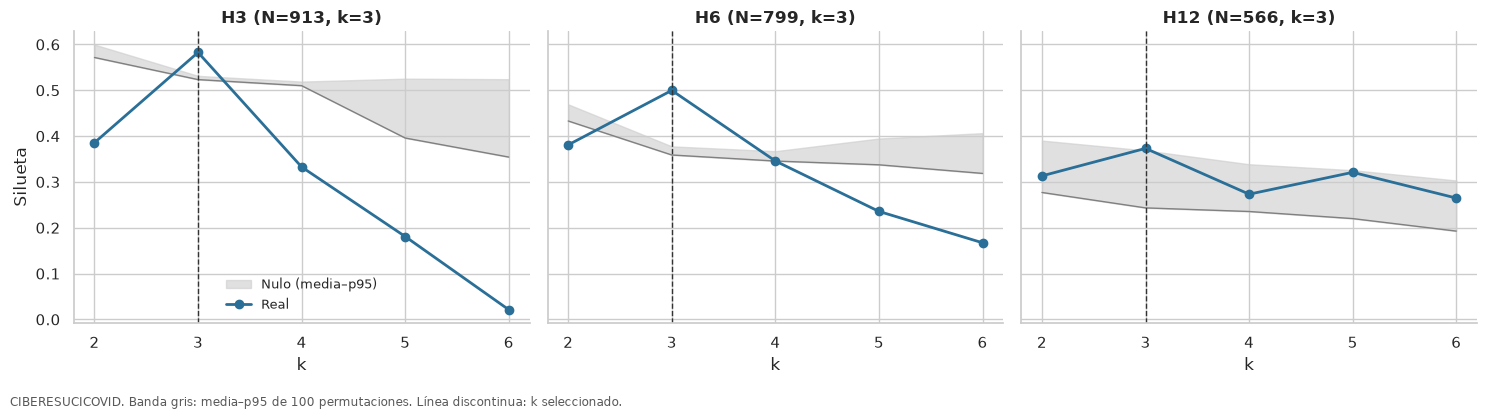

,Horizonte,k,silueta_real,nulo_media,nulo_p95,Ventaja frente al nulo,supera_p95,Elegido
0,H3,2,0.386,0.572,0.600,-0.186,False,False
1,H3,3,0.583,0.523,0.532,0.059,True,True
2,H3,4,0.333,0.510,0.519,-0.177,False,False
3,H3,5,0.181,0.396,0.525,-0.215,False,False
4,H3,6,0.021,0.354,0.524,-0.333,False,False
5,H6,2,0.381,0.433,0.469,-0.052,False,False
6,H6,3,0.500,0.359,0.378,0.141,True,True
7,H6,4,0.346,0.346,0.367,0.000,False,False
8,H6,5,0.236,0.337,0.395,-0.102,False,False
9,H6,6,0.167,0.319,0.406,-0.151,False,False


In [5]:
fig, axes = plt.subplots(
    1, len(HORIZONTES),
    figsize=(15, 4),
    sharey=True,
    squeeze=False
)
axes = axes.ravel()

tablas_k = []

for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]
    nl = r["nulo"].sort_values("k").copy()

    x = nl["k"].to_numpy(dtype=float)
    media = nl["nulo_media"].to_numpy(dtype=float)
    p95 = nl["nulo_p95"].to_numpy(dtype=float)
    real = nl["silueta_real"].to_numpy(dtype=float)

    ax.fill_between(
        x, media, p95,
        color="0.8", alpha=0.6,
        label="Nulo (media–p95)"
    )
    ax.plot(x, media, color="0.5", lw=1)
    ax.plot(
        x, real, "o-",
        color=COLOR[DESC], lw=2,
        label="Real"
    )
    ax.axvline(r["k"], color="0.2", ls="--", lw=1)

    ax.set_title(f"{h} (N={len(r['desc'])}, k={r['k']})")
    ax.set_xticks(KS)
    ax.set_xlabel("k")

    nl["Horizonte"] = h
    nl["Ventaja frente al nulo"] = (
        nl["silueta_real"] - nl["nulo_media"]
    )
    nl["Elegido"] = nl["k"].eq(r["k"])
    tablas_k.append(nl)

axes[0].set_ylabel("Silueta")
axes[0].legend(frameon=False, fontsize=9)

nota(
    axes[0],
    f"{DESC}. Banda gris: media–p95 de "
    f"{FC['n_permutaciones']} permutaciones. "
    "Línea discontinua: k seleccionado."
)
plt.tight_layout()
guardar(fig, "03_eleccion_k")
plt.show()

comparacion_k = pd.concat(tablas_k, ignore_index=True)

display(
    comparacion_k[[
        "Horizonte", "k", "silueta_real",
        "nulo_media", "nulo_p95",
        "Ventaja frente al nulo", "supera_p95", "Elegido"
    ]].round(3)
)

comparacion_k.to_csv(TAB / "03_comparacion_k.csv", index=False)

El procedimiento selecciona tres grupos en los tres horizontes. La comparación con datos permutados respalda que existe estructura conjunta en las variables, y la separación es más marcada en el horizonte temprano.

Perfiles de reproducibilidad

In [6]:
perfiles = []

for h, r in resultados.items():
    t = r["desc"][r["cols"]].copy()
    t["Fenotipo"] = [nombre_f(c) for c in r["lab"]]

    for fenotipo, grupo in t.groupby("Fenotipo", sort=True):
        n = len(grupo)

        for variable in r["cols"]:
            s = grupo[variable].dropna()
            suficiente = n >= N_MIN and len(s) >= N_MIN

            perfiles.append({
                "Horizonte": h,
                "Fenotipo": fenotipo,
                "Variable": variable,
                "N grupo": n if n >= N_MIN else np.nan,
                "N con dato": len(s) if suficiente else np.nan,
                "Mediana": s.median() if suficiente else np.nan,
                "P25": s.quantile(0.25) if suficiente else np.nan,
                "P75": s.quantile(0.75) if suficiente else np.nan,
                "Cobertura (%)": (
                    100 * len(s) / n if suficiente else np.nan
                ),
            })

perfiles = pd.DataFrame(perfiles)

for h in HORIZONTES:
    print(f"\n{h}: medianas por fenotipo")
    display(
        perfiles.loc[perfiles["Horizonte"].eq(h)]
        .pivot(index="Variable", columns="Fenotipo", values="Mediana")
        .round(2)
    )

perfiles.to_csv(TAB / "03_perfiles_clinicos.csv", index=False)


H3: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_M3,79.2,69.65,67.0
fatiga_M3,0.0,1.00,0.0
fvc_M3,93.0,85.60,84.0
resolucion_M3,0.0,1.00,1.0



H6: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_M3,67.00,65.0,63.0
dlco_M6,78.00,71.0,70.0
dlco_cambio,5.90,4.5,4.5
fatiga_M3,0.00,1.0,0.0
fatiga_M6,0.00,1.0,0.0
fvc_M3,91.15,82.0,84.0
fvc_M6,93.00,88.0,87.0
fvc_cambio,3.00,6.0,5.8
resolucion_M3,1.00,1.0,1.0



H12: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_A1,78.0,76.0,74.0
dlco_M3,69.0,67.0,65.0
dlco_M6,71.5,68.0,67.0
dlco_cambio,8.0,2.1,6.0
fatiga_M3,0.0,1.0,0.0
fatiga_M6,0.0,1.0,0.0
fvc_A1,94.0,93.0,83.0
fvc_M3,90.0,85.6,79.5
fvc_M6,91.0,87.0,85.0


F1 mantiene una función pulmonar más favorable, F2 se distingue por la fatiga y F3 por una menor DLCO. Sin embargo, esta similitud entre horizontes no demuestra que los mismos pacientes permanezcan en cada grupo.

Y para las variables binarias


In [7]:
filas_validacion = []

for h, r in resultados.items():
    fila = {
        "Horizonte": h,
        "Jaccard bootstrap mínimo": (
            r["estab"]["jaccard_medio"].min()
        ),
        "ARI solo DLCO/FVC": r["ari_solo_compartidas"],
    }

    for cohorte, out in r["replicas"].items():
        etiqueta = ETQ.get(cohorte, cohorte)
        fila[f"ARI transferencia vs nativo: {etiqueta}"] = out["ari"]
        fila[f"IC95 inferior: {etiqueta}"] = out["ari_ic"][0]
        fila[f"IC95 superior: {etiqueta}"] = out["ari_ic"][1]

    filas_validacion.append(fila)

validacion = pd.DataFrame(filas_validacion).set_index("Horizonte")
display(validacion.round(3))
validacion.to_csv(TAB / "03_validacion_fenotipos.csv")

,Jaccard bootstrap mínimo,ARI solo DLCO/FVC,ARI transferencia vs nativo: POSTCOVID-Lleida,IC95 inferior: POSTCOVID-Lleida,IC95 superior: POSTCOVID-Lleida,ARI transferencia vs nativo: TENACITY,IC95 inferior: TENACITY,IC95 superior: TENACITY
Horizonte,,,,,,,,
H3,0.980,0.008,0.168,0.132,0.239,0.200,0.059,0.273
H6,0.998,0.004,0.239,0.051,0.304,0.293,0.047,0.386
H12,0.623,0.036,0.287,0.071,0.390,0.281,0.017,0.430


Los fenotipos presentan una elevada estabilidad interna en H3 y H6, con Jaccard mínimos de 0,980 y 0,998, pero menor estabilidad en H12, con 0,623. Su transferencia a Lleida y TENACITY muestra una concordancia limitada con los agrupamientos propios de esas cohortes, aunque los intervalos de confianza excluyen cero. Además, los ARI próximos a cero al utilizar solo DLCO y FVC indican que estas variables no bastan para recuperar los fenotipos originales: la estabilidad dentro de CIBERESUCICOVID no implica que los grupos sean directamente reproducibles en otras poblaciones.

Transiciones entre horizontes de tiempo de 3, 6 y 12 meses

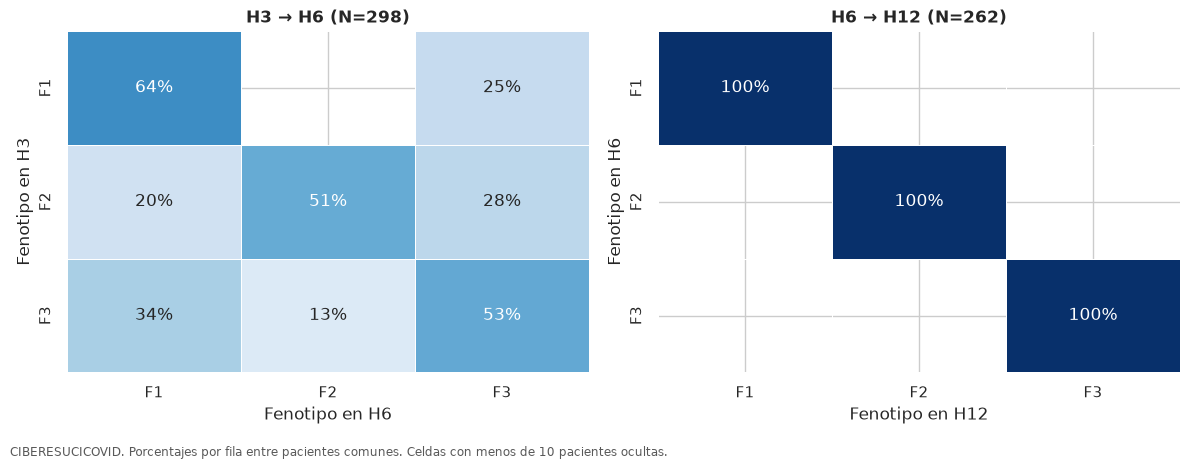

,N inicial,Pacientes comunes,% inicial con etiqueta posterior,ARI
Transición,,,,
H3 → H6,913,298,32.64,0.11
H6 → H12,799,262,32.79,1.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
filas = []
tablas_transicion = {}

for ax, (h1, h2) in zip(
    axes, [("H3", "H6"), ("H6", "H12")]
):
    r1, r2 = resultados[h1], resultados[h2]

    e1 = pd.Series(
        [nombre_f(c) for c in r1["lab"]],
        index=r1["desc"].index,
        name=h1
    )
    e2 = pd.Series(
        [nombre_f(c) for c in r2["lab"]],
        index=r2["desc"].index,
        name=h2
    )

    assert e1.index.is_unique and e2.index.is_unique

    tabla, ari, n = P.transiciones(e1, e2)

    filas.append({
        "Transición": f"{h1} → {h2}",
        "N inicial": len(e1),
        "Pacientes comunes": n,
        "% inicial con etiqueta posterior": (
            100 * n / len(e1) if len(e1) else np.nan
        ),
        "ARI": ari,
    })

    if n:
        tabla = tabla.reindex(
            index=[nombre_f(c) for c in range(r1["k"])],
            columns=[nombre_f(c) for c in range(r2["k"])],
            fill_value=0
        )

        denominador = tabla.sum(axis=1).replace(0, np.nan)
        pct = tabla.div(denominador, axis=0).mul(100)

        ocultar = tabla.lt(N_MIN) | pct.isna()
        anotaciones = pct.map(
            lambda v: "" if pd.isna(v) else f"{v:.0f}%"
        ).mask(ocultar, "")

        sns.heatmap(
            pct,
            mask=ocultar,
            annot=anotaciones.to_numpy(),
            fmt="",
            cmap="Blues",
            vmin=0, vmax=100,
            cbar=False,
            linewidths=0.5,
            ax=ax
        )

        tabla_publica = tabla.astype(float).mask(tabla < N_MIN)
        tablas_transicion[(h1, h2)] = tabla_publica
        tabla_publica.to_csv(
            TAB / f"03_transiciones_{h1}_{h2}_conteos.csv"
        )
    else:
        ax.text(
            0.5, 0.5, "Sin pacientes comunes",
            ha="center", va="center",
            transform=ax.transAxes
        )

    ax.set_xlabel(f"Fenotipo en {h2}")
    ax.set_ylabel(f"Fenotipo en {h1}")
    ax.set_title(f"{h1} → {h2} (N={n})")

nota(
    axes[0],
    f"{DESC}. Porcentajes por fila entre pacientes comunes. "
    f"Celdas con menos de {N_MIN} pacientes ocultas."
)
plt.tight_layout()
guardar(fig, "03_transiciones")
plt.show()

resumen_transiciones = pd.DataFrame(filas).set_index("Transición")
resumen_transiciones_publico = privacidad.suprimir_celdas(
    resumen_transiciones.round(2),
    N_MIN,
    ["N inicial", "Pacientes comunes"]
)

display(resumen_transiciones_publico)
resumen_transiciones_publico.to_csv(
    TAB / "03_resumen_transiciones.csv"
)

Entre H3 y H6, la concordancia de las agrupaciones es baja (ARI = 0,11), mientras que entre H6 y H12 es completa en los pacientes comunes (ARI = 1,00), lo que sugiere una mayor continuidad de la partición en los horizontes posteriores. Sin embargo, cada comparación incluye solo alrededor del 33% de los pacientes iniciales y los horizontes comparten información previa, por lo que no puede interpretarse como estabilidad clínica de toda la cohorte ni como capacidad predictiva demostrada.

En conjunto, identificamos tres perfiles estables en los horizontes tempranos de CIBERESUCICOVID, pero su limitada transferencia indica que no basta con trasladar los grupos originales utilizando solo las variables respiratorias. 

Esto justifica avanzar hacia fenotipado_comun, realizando el clustering conjuntamente en CIBERESUCICOVID, POSTCOVID-Lleida y TENACITY, utilizando las variables comparables entre las tres cohortes. Así buscamos perfiles comunes desde su definición, cuya estabilidad y reproducibilidad entre cohortes deberán validarse antes de utilizarlos para predecir la evolución a largo plazo.



### 2.2 Clusterización en todos los datasets

Criterios fijados **antes** de ver los resultados (`config.yaml → fenotipado_comun`).

#### 2.2.1 Pacientes y comparabilidad de las variables

In [3]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
tablas_var = {}
for h in HORIZONTES:
    partes = [FP.construir_variables(medidas, pacientes, cfg, PF, h, c) for c in COHORTES]
    tablas_var[h] = (pd.concat([t for t, _ in partes]), partes[0][1])
    limite = PF["visitas"][PF["horizontes"][h][-1]]["ventana"][1]
    assert tablas_var[h][0]["dias_max"].max() <= limite, "fuga de datos futuros"
    assert tablas_var[h][0].index.is_unique, "paciente duplicado entre cohortes"
print("Comprobado: sin datos posteriores al horizonte y sin pacientes duplicados entre cohortes.")
n_tabla = pd.DataFrame({h: tablas_var[h][0]["cohorte_analisis"].astype(str).value_counts().rename(ETQ) for h in HORIZONTES})
n_tabla.loc["Total"] = n_tabla.sum()
privacidad.suprimir_celdas(n_tabla, N_MIN, HORIZONTES)

Comprobado: sin datos posteriores al horizonte y sin pacientes duplicados entre cohortes.


,H3,H6,H12
cohorte_analisis,,,
CIBERESUCICOVID,956,860,567
POSTCOVID-Lleida,464,384,301
TENACITY,154,60,66
Total,1574,1304,934


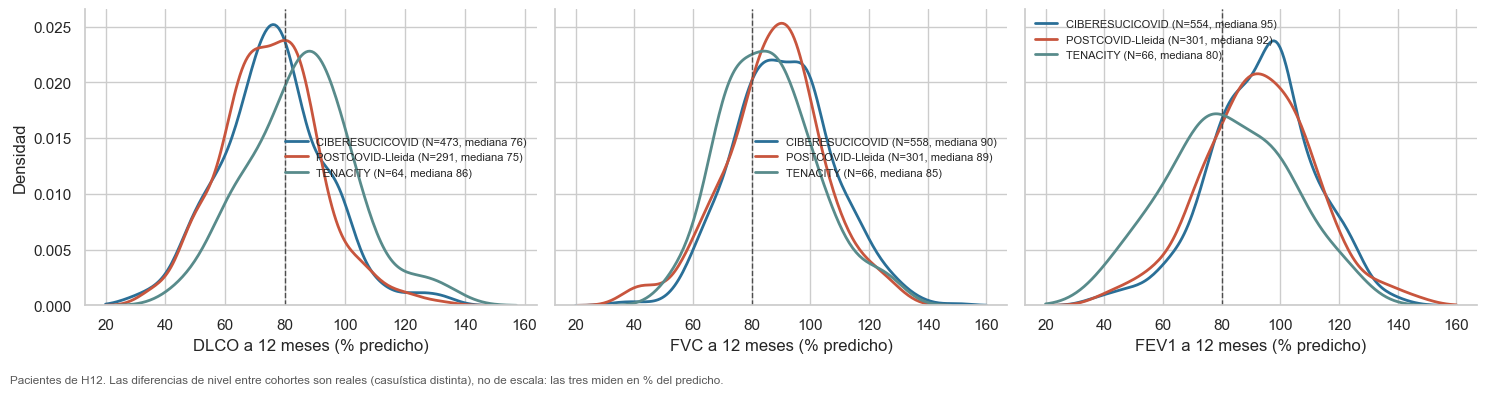

In [4]:
# ¿Se miden igual en las tres cohortes? Distribución de cada variable en la última visita de H12
t12, _ = tablas_var["H12"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, v in zip(axes, ["dlco", "fvc", "fev1"]):
    for c in COHORTES:
        s = t12.loc[t12["cohorte_analisis"] == c, f"{v}_T12"].dropna()
        if len(s) >= N_MIN:
            sns.kdeplot(s, ax=ax, color=COLOR[c], lw=2, label=f"{ETQ[c]} (N={len(s)}, mediana {s.median():.0f})", clip=(20, 160))
    ax.axvline(80, color="0.3", ls="--", lw=1); ax.set_xlabel(f"{v.upper()} a 12 meses (% predicho)"); ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Densidad")
nota(fig, "Pacientes de H12. Las diferencias de nivel entre cohortes son reales (casuística distinta), no de escala: "
          "las tres miden en % del predicho.")
plt.tight_layout(); guardar(fig, "distribuciones"); plt.show()

#### 2.2.2 Los tres clusterings (todas las cohortes juntas)

In [5]:
def ejecutar(h: str, k_forzado: int | None = None, columnas: list[str] | None = None, excluir: str | None = None,
             filtro=None, n_perm: int | None = None, n_boot: int | None = None) -> dict:
    """Clustering conjunto de un horizonte: k contra el nulo, PAM y estabilidad bootstrap."""
    t, cols = tablas_var[h]
    cols = columnas or cols
    if excluir is not None:
        t = t[t["cohorte_analisis"] != excluir]
    if filtro is not None:
        t = t[filtro(t)]
    t = t[t[cols].notna().any(axis=1)]
    X = t[cols].to_numpy(float)
    R, w, cat = FP.parametros_gower(cols, PF)
    D = FP.gower(X, None, R, w, cat)
    nulo = FP.seleccion_k_nulo(X, R, w, cat, KS, n_perm or PF["n_permutaciones"], SEMILLA, D)
    k, estructura = (k_forzado, bool(nulo.set_index("k").loc[k_forzado, "supera_p95"])) if k_forzado else FP.elegir_k(nulo)
    lab, med = FP.pam(D, k, SEMILLA)
    ultima = PF["horizontes"][h][-1]
    lab, med = FP.ordenar_por_dlco(lab, med, t[f"dlco_{ultima}"].to_numpy(float))
    return {"h": h, "cols": cols, "R": R, "w": w, "cat": cat, "desc": t, "X": X, "D": D, "nulo": nulo, "k": k,
            "estructura": estructura, "lab": lab, "med": med, "silueta": FP.silueta(D, lab),
            "estab": FP.estabilidad_bootstrap(D, lab, k, n_boot or PF["n_bootstrap"], SEMILLA)}


resultados = {h: ejecutar(h) for h in HORIZONTES}
for h, r in resultados.items():
    print(f"{h}: N = {len(r['desc'])}, k = {r['k']}, estructura frente al nulo = {'sí' if r['estructura'] else 'NO'}, "
          f"silueta = {r['silueta']:.2f} (nula {r['nulo'].set_index('k').loc[r['k'], 'nulo_media']:.2f})")

H3: N = 1574, k = 2, estructura frente al nulo = sí, silueta = 0.36 (nula 0.11)
H6: N = 1304, k = 4, estructura frente al nulo = sí, silueta = 0.17 (nula 0.03)
H12: N = 934, k = 2, estructura frente al nulo = sí, silueta = 0.29 (nula 0.05)


#### 2.2.3 Elección de k: silueta real frente a la nula

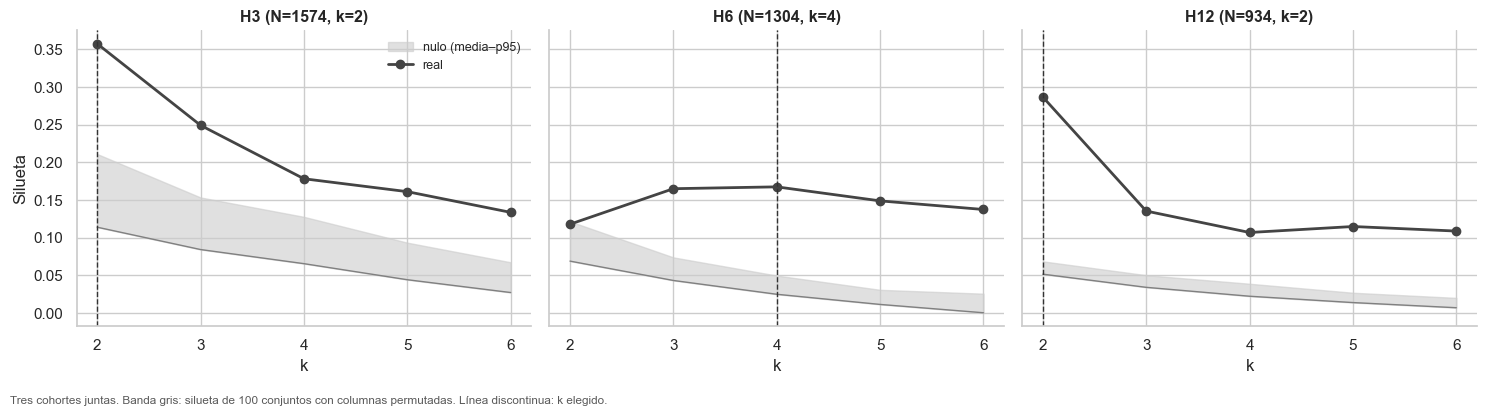

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]; nl = r["nulo"]
    ax.fill_between(nl["k"], nl["nulo_media"], nl["nulo_p95"], color="0.8", alpha=0.6, label="nulo (media–p95)")
    ax.plot(nl["k"], nl["nulo_media"], color="0.5", lw=1)
    ax.plot(nl["k"], nl["silueta_real"], "o-", color="#444", lw=2, label="real")
    ax.axvline(r["k"], color="0.2", ls="--", lw=1)
    ax.set_title(f"{h} (N={len(r['desc'])}, k={r['k']})"); ax.set_xticks(KS); ax.set_xlabel("k")
axes[0].set_ylabel("Silueta"); axes[0].legend(frameon=False, fontsize=9)
nota(fig, f"Tres cohortes juntas. Banda gris: silueta de {PF['n_permutaciones']} conjuntos con columnas permutadas. "
          "Línea discontinua: k elegido.")
plt.tight_layout(); guardar(fig, "eleccion_k"); plt.show()

#### 2.2.4 Perfiles de los fenotipos

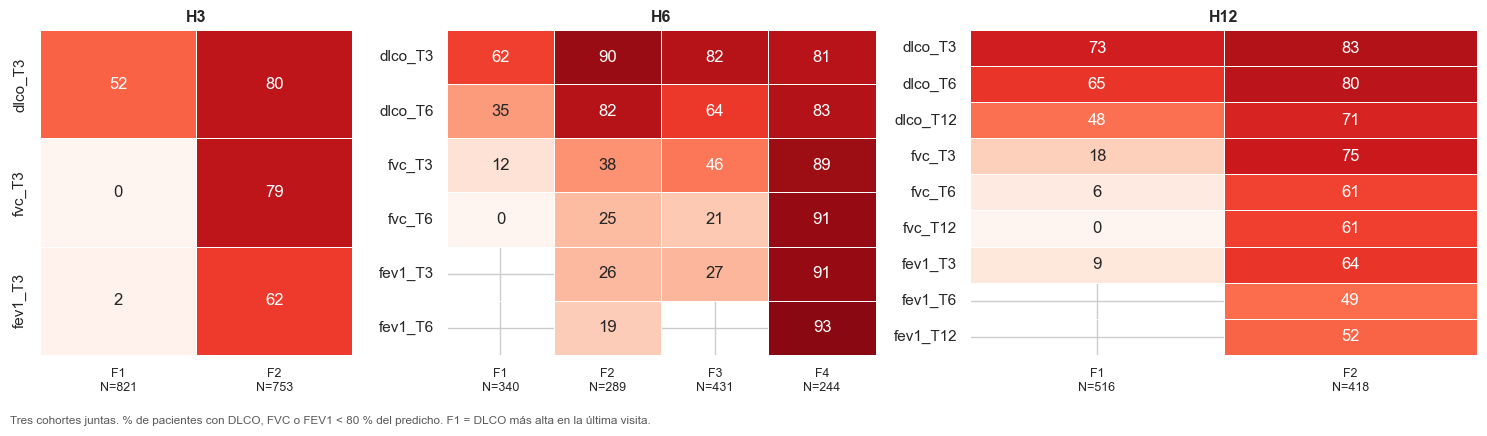

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw={"width_ratios": [0.8, 1.1, 1.3]})
for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]
    pct, n_alt = FP.porcentaje_alterado(r["desc"], r["cols"], r["lab"], cfg)
    tam = pd.Series(r["lab"]).value_counts().sort_index()
    oculta = (n_alt > 0) & (n_alt < N_MIN)
    oculta.loc[:, tam[tam < N_MIN].index] = True
    etiquetas = pct.round(0).astype("Int64").astype(str).mask(oculta, "<10")
    visible = pct.mask(oculta)
    visible.columns = [f"{nombre_f(c)}\nN={tam[c] if tam[c] >= N_MIN else '<10'}" for c in pct.columns]
    sns.heatmap(visible, annot=etiquetas.values, fmt="", cmap="Reds", vmin=0, vmax=100, cbar=False, ax=ax, linewidths=0.5)
    ax.set_title(h); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=0, labelsize=9)
nota(fig, "Tres cohortes juntas. % de pacientes con DLCO, FVC o FEV1 < 80 % del predicho. F1 = DLCO más alta en la última visita.")
plt.tight_layout(); guardar(fig, "perfiles"); plt.show()

In [8]:
filas = []
for h, r in resultados.items():
    for c, fila in r["desc"][r["cols"]].groupby(r["lab"]).median().iterrows():
        if (r["lab"] == c).sum() >= N_MIN:
            filas.append({"horizonte": h, "fenotipo": nombre_f(c), "N": int((r["lab"] == c).sum()), **fila.round(1).to_dict()})
medianas = pd.DataFrame(filas).set_index(["horizonte", "fenotipo"])
medianas.to_csv(TAB / f"{PFX}_medianas_fenotipos.csv")
medianas

N  dlco_T3  fvc_T3  fev1_T3  dlco_T6  dlco_cambio  fvc_T6  fvc_cambio  fev1_T6  fev1_cambio  dlco_T12  fvc_T12  fev1_T12
horizonte fenotipo                                                                                                                            
H3        F1        821     79.0    96.0     99.0      NaN          NaN     NaN         NaN      NaN          NaN       NaN      NaN       NaN
          F2        753     65.0    73.0     76.0      NaN          NaN     NaN         NaN      NaN          NaN       NaN      NaN       NaN
H6        F1        340     72.6    94.0    100.0     86.6          7.9   100.0         7.0    106.0          7.4       NaN      NaN       NaN
          F2        289     69.0    86.8     93.0     74.0          4.1    91.0         6.0     97.0          5.0       NaN      NaN       NaN
          F3        431     64.4    81.0     86.0     68.5          4.0    85.0         3.2     90.0          4.0       NaN      NaN       NaN
          F4        244     58.6    67.0     67.0     59.0          2.0    69.0         3.0     70.7          2.0       NaN      NaN       NaN
H12       F1        516     71.0    90.5     95.0     72.0          7.0    94.0         7.0    101.0          7.0      80.0     99.1     102.3
          F2        418     63.6    72.0     74.0     66.0          6.0    76.4         3.0     80.0          3.0      71.0     77.0      79.0

#### 2.2.5 ¿Los fenotipos separan pacientes o cohortes?

Si los grupos solo reflejaran la cohorte (por ejemplo, "los de TENACITY" frente a "los de CIBERESUCICOVID"), no servirían para predecir pacientes de cualquier cohorte. Se comprueban dos cosas:
- **Composición:** % de cada cohorte en cada fenotipo y V de Cramér.
- **Perfil por cohorte:** cómo es cada fenotipo dentro de cada cohorte. Si el fenotipo es real, las medianas deben ser parecidas.

In [9]:
filas = []
for h, r in resultados.items():
    coh = r["desc"]["cohorte_analisis"].astype(str).map(ETQ).values
    ct = pd.crosstab(pd.Series([nombre_f(c) for c in r["lab"]], name="fenotipo"), pd.Series(coh, name="cohorte"))
    filas.append({"horizonte": h, "V de Cramér (fenotipo × cohorte)": round(cramer_v(ct), 2)})
    pct = (ct.div(ct.sum(axis=0), axis=1) * 100).round(1).mask(ct < N_MIN)
    print(f"\n=== {h}: % de cada cohorte en cada fenotipo (columnas suman 100) ===")
    display(pct)
pd.DataFrame(filas).set_index("horizonte")


=== H3: % de cada cohorte en cada fenotipo (columnas suman 100) ===


cohorte,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY
fenotipo,,,
F1,56.8,44.2,47.4
F2,43.2,55.8,52.6



=== H6: % de cada cohorte en cada fenotipo (columnas suman 100) ===


cohorte,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY
fenotipo,,,
F1,29.3,20.1,18.3
F2,20.5,25.5,25.0
F3,33.7,32.8,25.0
F4,16.5,21.6,31.7



=== H12: % de cada cohorte en cada fenotipo (columnas suman 100) ===


cohorte,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY
fenotipo,,,
F1,57.3,55.1,37.9
F2,42.7,44.9,62.1


,V de Cramér (fenotipo × cohorte)
horizonte,
H3,0.12
H6,0.10
H12,0.10


In [10]:
filas = []
for h, r in resultados.items():
    d = r["desc"].assign(fenotipo=[nombre_f(c) for c in r["lab"]])
    ultima = PF["horizontes"][h][-1]
    for (fen, coh), g in d.groupby(["fenotipo", "cohorte_analisis"], observed=True):
        if len(g) >= N_MIN:
            filas.append({"horizonte": h, "fenotipo": fen, "cohorte": ETQ[str(coh)], "N": len(g),
                          **{f"{v}_{ultima} (mediana)": round(g[f"{v}_{ultima}"].median(), 1) for v in ["dlco", "fvc", "fev1"]}})
perfil_cohorte = pd.DataFrame(filas).set_index(["horizonte", "fenotipo", "cohorte"])
perfil_cohorte.to_csv(TAB / f"{PFX}_perfil_por_cohorte.csv")
perfil_cohorte

N  dlco_T3 (mediana)  fvc_T3 (mediana)  fev1_T3 (mediana)  dlco_T6 (mediana)  fvc_T6 (mediana)  fev1_T6 (mediana)  dlco_T12 (mediana)  fvc_T12 (mediana)  fev1_T12 (mediana)
horizonte fenotipo cohorte                                                                                                                                                                                         
H3        F1       CIBERESUCICOVID   543               78.0              97.0               99.0                NaN               NaN                NaN                 NaN                NaN                 NaN
                   POSTCOVID-Lleida  205               78.1              93.0              100.0                NaN               NaN                NaN                 NaN                NaN                 NaN
                   TENACITY           73               87.5              96.0               96.0                NaN               NaN                NaN                 NaN                NaN                 NaN
          F2       CIBERESUCICOVID   413               64.0              73.0               76.0                NaN               NaN                NaN                 NaN                NaN                 NaN
                   POSTCOVID-Lleida  259               63.8              73.0               77.7                NaN               NaN                NaN                 NaN                NaN                 NaN
                   TENACITY           81               74.0              74.0               68.0                NaN               NaN                NaN                 NaN                NaN                 NaN
H6        F1       CIBERESUCICOVID   252                NaN               NaN                NaN               87.0             100.0              106.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida   77                NaN               NaN                NaN               84.0              98.7              107.0                 NaN                NaN                 NaN
                   TENACITY           11                NaN               NaN                NaN               98.0             107.0              105.0                 NaN                NaN                 NaN
          F2       CIBERESUCICOVID   176                NaN               NaN                NaN               75.0              92.5               98.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida   98                NaN               NaN                NaN               73.6              87.0               94.7                 NaN                NaN                 NaN
                   TENACITY           15                NaN               NaN                NaN               72.0              89.0               80.0                 NaN                NaN                 NaN
          F3       CIBERESUCICOVID   290                NaN               NaN                NaN               68.0              85.0               90.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida  126                NaN               NaN                NaN               69.0              84.0               90.0                 NaN                NaN                 NaN
                   TENACITY           15                NaN               NaN                NaN               86.0              87.0               88.0                 NaN                NaN                 NaN
          F4       CIBERESUCICOVID   142                NaN               NaN                NaN               59.0              69.0               71.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida   83                NaN               NaN                NaN               58.0              67.0               70.0                 NaN                NaN                 NaN
           

#### 2.2.6 Estabilidad y validación dejando fuera cada cohorte

In [11]:
filas = []
for h, r in resultados.items():
    for _, e in r["estab"].iterrows():
        filas.append({"horizonte": h, "fenotipo": nombre_f(int(e["cluster"])), "N": int(e["n"]),
                      "Jaccard medio": round(e["jaccard_medio"], 2), "Jaccard p05": round(e["jaccard_p05"], 2)})
estab = pd.DataFrame(filas)
estab["veredicto"] = pd.cut(estab["Jaccard medio"], [0, 0.5, 0.75, 1.01], labels=["se disuelve", "patrón", "estable"])
estab.to_csv(TAB / f"{PFX}_estabilidad.csv", index=False)
privacidad.suprimir_celdas(estab.set_index(["horizonte", "fenotipo"]), N_MIN, ["N"])

N  Jaccard medio  Jaccard p05 veredicto
horizonte fenotipo                                           
H3        F1        821           0.92         0.49   estable
          F2        753           0.92         0.48   estable
H6        F1        340           0.81         0.57   estable
          F2        289           0.57         0.18    patrón
          F3        431           0.77         0.47   estable
          F4        244           0.74         0.47    patrón
H12       F1        516           0.89         0.75   estable
          F2        418           0.89         0.71   estable

**Dejar fuera una cohorte** (la prueba principal de este notebook). Para cada horizonte y cada cohorte:
1. Se agrupa solo con las **otras dos** cohortes (mismo k).
2. La cohorte excluida se **transfiere** a esos medoides.
3. Se compara:
   - con su **propio clustering nativo** (ARI con IC bootstrap): ¿la cohorte nueva tiene la misma estructura?;
   - con las **etiquetas del clustering conjunto** (ARI): ¿cambian sus etiquetas por haberla incluido?

In [12]:
filas = []
loco = {}
for h, r in resultados.items():
    t = r["desc"]
    for c in COHORTES:
        dentro = (t["cohorte_analisis"] == c).values
        if dentro.sum() < 2 * r["k"]:
            continue
        X_otros, X_c = r["X"][~dentro], r["X"][dentro]
        D_otros = r["D"][np.ix_(~dentro, ~dentro)]
        lab_o, med_o = FP.pam(D_otros, r["k"], SEMILLA)
        lab_o, med_o = FP.ordenar_por_dlco(lab_o, med_o, t.loc[~dentro, f"dlco_{PF['horizontes'][h][-1]}"].to_numpy(float))
        out = P.replicar(X_otros, med_o, X_c, r["R"], r["w"], r["cat"], r["k"], PF["n_bootstrap"], SEMILLA)
        loco[(h, c)] = out
        filas.append({"horizonte": h, "cohorte excluida": ETQ[c], "N": int(dentro.sum()), "k": r["k"],
                      "ARI transferidas frente a nativas": round(out["ari"], 2),
                      "IC95": f"{out['ari_ic'][0]:.2f} a {out['ari_ic'][1]:.2f}",
                      "ARI frente al clustering conjunto": round(adjusted_rand_score(r["lab"][dentro], out["transferidas"]), 2),
                      "Jaccard por fenotipo": " / ".join(f"{j:.2f}" for j in out["jaccard"])})
validacion = pd.DataFrame(filas).set_index(["horizonte", "cohorte excluida"])
validacion.to_csv(TAB / f"{PFX}_validacion_loco.csv")
validacion

N  k  ARI transferidas frente a nativas          IC95  ARI frente al clustering conjunto       Jaccard por fenotipo
horizonte cohorte excluida                                                                                                                       
H3        CIBERESUCICOVID   956  2                               0.50   0.26 a 0.62                               0.56                0.79 / 0.68
          POSTCOVID-Lleida  464  2                               0.61   0.26 a 0.81                               0.95                0.80 / 0.81
          TENACITY          154  2                               0.73   0.18 a 0.87                               1.00                0.87 / 0.87
H6        CIBERESUCICOVID   860  4                               0.30   0.25 a 0.48                               0.27  0.40 / 0.51 / 0.54 / 0.03
          POSTCOVID-Lleida  384  4                               0.30   0.23 a 0.44                               0.89  0.33 / 0.05 / 0.52 / 0.54
          TENACITY           60  4                               0.27   0.07 a 0.37                               1.00  0.73 / 0.27 / 0.41 / 0.50
H12       CIBERESUCICOVID   567  2                               0.34   0.20 a 0.45                               0.37                0.69 / 0.61
          POSTCOVID-Lleida  301  2                               0.21   0.04 a 0.70                               1.00                0.60 / 0.54
          TENACITY           66  2                               0.05  -0.06 a 0.63                               0.77                0.45 / 0.48

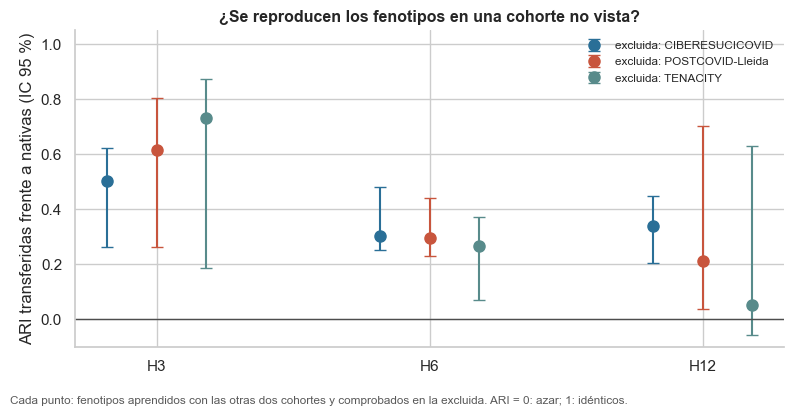

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, c in enumerate(COHORTES):
    xs, ys, lo, hi = [], [], [], []
    for j, h in enumerate(HORIZONTES):
        out = loco.get((h, c))
        if out is None:
            continue
        xs.append(j + (i - 1) * 0.18); ys.append(out["ari"])
        lo.append(out["ari"] - out["ari_ic"][0]); hi.append(out["ari_ic"][1] - out["ari"])
    ax.errorbar(xs, ys, yerr=[lo, hi], fmt="o", ms=8, capsize=4, color=COLOR[c], label=f"excluida: {ETQ[c]}")
ax.axhline(0, color="0.3", lw=1); ax.set_xticks(range(len(HORIZONTES)), HORIZONTES); ax.set_ylim(-0.1, 1.05)
ax.set_ylabel("ARI transferidas frente a nativas (IC 95 %)"); ax.set_title("¿Se reproducen los fenotipos en una cohorte no vista?")
ax.legend(frameon=False, fontsize=8.5)
nota(fig, "Cada punto: fenotipos aprendidos con las otras dos cohortes y comprobados en la excluida. ARI = 0: azar; 1: idénticos.")
plt.tight_layout(); guardar(fig, "validacion_loco"); plt.show()

#### 2.2.7 Fichas: los fenotipos descritos en cada cohorte

Cada cohorte describe los fenotipos con lo que recoge y no entra en la definición:
- CIBERESUCICOVID: fatiga, resolución, reingresos y TAC.
- Lleida y TENACITY: HADS, mMRC, PM6M, astenia y fibrosis.
- Todas: datos del ingreso.

In [14]:
VARS_DEF = set(FP.variables_definicion(PF))
IMAGEN = ("tac_", "tractos", "fibrosis")


def ficha(h: str, cohorte: str, datos: pd.DataFrame, etiquetas: np.ndarray, k: int) -> pd.DataFrame:
    visitas = PF["horizontes"][h]
    p = pacientes.set_index("subject_id").reindex(datos.index)
    seguimiento = {}
    for regla in ["alguna", "ultima"]:
        for v in PF["descripcion"][regla]:
            if v not in VARS_DEF and (v.startswith(IMAGEN) or FP.visitas_que_recogen(cfg, PF, v, cohorte)):
                seguimiento[v] = FP.estado_hasta(medidas, cfg, PF, cohorte, datos.index, v, visitas, regla)
    filas = {}
    for c in range(k):
        s = etiquetas == c
        sub = p[s]
        col = {"N": int(s.sum())}
        if s.sum() >= N_MIN:
            col["Edad ≥ 65 (%)"] = pct_seguro(sub["grupo_edad"].isin(["65-74", ">=75"]).astype(float).where(sub["grupo_edad"].notna()))
            col["Mujeres (%)"] = pct_seguro((sub["sexo"] == 1).astype(float).where(sub["sexo"].notna()))
            col["Estancia (mediana, días)"] = sub["estancia_hosp_dias"].median()
            for v in PF["descripcion"]["ingreso_binarias"]:
                col[f"{v.replace('nu_', '')} (%)"] = pct_seguro(sub[v])
            for v, serie in seguimiento.items():
                col[f"{v} (% sí / alterado)"] = pct_seguro(serie[s])
        filas[nombre_f(c)] = col
    return pd.DataFrame(filas).round(1)


fichas = {}
for h, r in resultados.items():
    bloques = {}
    for c in COHORTES:
        dentro = (r["desc"]["cohorte_analisis"] == c).values
        fichas[(h, c)] = ficha(h, c, r["desc"][dentro], r["lab"][dentro], r["k"])
        bloques[ETQ[c]] = fichas[(h, c)]
    print(f"\n=== {h} ===")
    display(pd.concat(bloques, axis=1).dropna(how="all"))
pd.concat({f"{h}|{c}": f for (h, c), f in fichas.items()}, names=["horizonte|cohorte", "variable"]).to_csv(TAB / f"{PFX}_fichas.csv")


=== H3 ===


CIBERESUCICOVID        POSTCOVID-Lleida        TENACITY       
                                                    F1     F2               F1     F2       F1     F2
N                                                543.0  413.0            205.0  259.0     73.0   81.0
Edad ≥ 65 (%)                                     31.9   29.5             33.7   34.9     45.3   30.4
Mujeres (%)                                       31.4   24.0             37.0   26.1     46.0   33.8
Estancia (mediana, días)                          24.0   34.0             14.0   18.0     18.0   19.0
ingreso_uci (%)                                  100.0  100.0             79.5   75.6    100.0  100.0
traqueo (%)                                       24.3   40.0             12.6   19.3     31.6   31.4
hta (%)                                           40.5   46.7             38.6   53.2     37.0   51.9
diabetes (%)                                      12.5   18.9             17.3   24.6     24.7   29.6
epoc (%)                                           3.5    5.8              NaN    7.5      NaN   25.9
card_cronica (%)                                   9.2   11.9              7.1    6.3      NaN   17.3
renal_cronica (%)                                  2.0    6.8              NaN    4.0      NaN   12.3
reingreso (% sí / alterado)                        3.3    4.4              NaN    NaN      NaN    NaN
urgencias (% sí / alterado)                       15.2   16.8              NaN    NaN      NaN    NaN
compl_cardiovascular (% sí / alterado)             3.2    3.2              NaN    NaN      NaN    NaN
compl_infecciosa (% sí / alterado)                 2.8    4.2              NaN    NaN      NaN    NaN
tac_normalizado (% sí / alterado)                 19.7   13.6              NaN    NaN      NaN    NaN
tac_infiltrados (% sí / alterado)                 28.5   25.6              NaN    NaN      NaN    NaN
tac_epid (% sí / alterado)                         6.3    8.5              NaN    NaN      NaN    NaN
tractos_fibrosos (% sí / alterado)                16.3   30.2              NaN    NaN      NaN    NaN
fibrosis_estricta (% sí / alterado)                NaN    NaN             13.2   29.2      NaN    0.0
fibrosis_amplia (% sí / alterado)                  NaN    NaN             57.1   75.7      NaN    NaN
fatiga (% sí / alterado)                          37.1   42.9              NaN    NaN      NaN    NaN
resolucion (% sí / alterado)                      66.0   79.3              NaN    NaN      NaN    NaN
astenia (% sí / alterado)                          NaN    NaN              NaN    NaN     18.8   27.0
fatiga_muscular (% sí / alterado)                  NaN    NaN             24.2   20.7      NaN    NaN
hads_a (% sí / alterado)                           NaN    NaN             17.6   18.2     24.3   16.7
hads_d (% sí / alterado)                           NaN    NaN             11.2   13.6     15.5    NaN
mmrc (% sí / alterado)                             NaN    NaN             14.4   27.8      NaN   26.4
pm6m (% sí / alterado)                             NaN    NaN             28.4   38.6     43.1   50.0


=== H6 ===


CIBERESUCICOVID                      POSTCOVID-Lleida                    TENACITY                     
                                                    F1     F2     F3     F4               F1    F2     F3    F4       F1     F2     F3     F4
N                                                252.0  176.0  290.0  142.0             77.0  98.0  126.0  83.0     11.0   15.0   15.0   19.0
Edad ≥ 65 (%)                                     36.9   38.6   32.1   35.2             52.6  34.7   40.7  33.3      NaN    NaN    NaN    NaN
Mujeres (%)                                       36.5   30.7   25.5   21.8             37.3  29.9   30.9  20.0      NaN    NaN    NaN    NaN
Estancia (mediana, días)                          24.0   29.0   31.0   39.0             15.5  16.0   18.0  21.0     17.0   24.0   24.0   21.0
ingreso_uci (%)                                  100.0  100.0  100.0  100.0             68.8  73.5   73.8  81.9    100.0  100.0  100.0  100.0
traqueo (%)                                       24.2   34.1   40.1   42.3              NaN  20.3   20.2  28.4      NaN    NaN    NaN    NaN
hta (%)                                           38.5   44.9   47.6   47.9             57.7  35.1   50.0  58.5      NaN    NaN    NaN    NaN
diabetes (%)                                      15.1   17.6   23.4   24.6             24.3  17.0   21.8  24.4      NaN    NaN    NaN    NaN
epoc (%)                                           NaN    NaN    3.8    9.9              NaN   NaN    NaN   NaN      0.0    NaN    0.0    NaN
card_cronica (%)                                   5.2   10.8   12.1   18.3              NaN   NaN    NaN   NaN      0.0    NaN    NaN    0.0
renal_cronica (%)                                  NaN    NaN    3.4    9.9              NaN   NaN    NaN   NaN      0.0    NaN    NaN    NaN
reingreso (% sí / alterado)                        4.4    6.9    8.3    8.6              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
urgencias (% sí / alterado)                       21.1   28.2   24.2   26.4              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
compl_cardiovascular (% sí / alterado)             5.2    NaN    3.8    9.3              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
compl_infecciosa (% sí / alterado)                 NaN    7.5    7.6    7.1              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
tac_normalizado (% sí / alterado)                 22.1   19.7   19.5   16.7              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
tac_infiltrados (% sí / alterado)                 33.8   31.6   35.3   28.9              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
tac_epid (% sí / alterado)                         7.1    8.5    NaN   14.4              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
tractos_fibrosos (% sí / alterado)                22.7   26.5   30.0   28.9              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
fibrosis_estricta (% sí / alterado)                NaN    NaN    NaN    NaN              NaN  37.0   28.6  43.2      NaN    NaN    NaN    NaN
fibrosis_amplia (% sí / alterado)                  NaN    NaN    NaN    NaN             73.3  82.6   73.2  84.1      NaN    NaN    NaN    NaN
fatiga (% sí / alterado)                          35.5   33.7   34.5   43.8              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
resolucion (% sí / alterado)                      59.2   65.1   66.5   80.6              NaN   NaN    NaN   NaN      NaN    NaN    NaN    NaN
fatiga_muscular (% sí / alterado)                  NaN    NaN    NaN    NaN             21.1  22.9   19.2  20.3      NaN    NaN    NaN    NaN
hads_a (% sí / alterado)                           NaN    NaN    NaN    NaN              NaN  16.7   13.9  19.5      0.0    NaN    NaN    NaN
hads_d (% sí / alterado)                           NaN    NaN    NaN    NaN              NaN  12.5    9.8  15.6      0.0    NaN    NaN    NaN
mmrc (% sí / alterado)                             NaN    NaN  


=== H12 ===


CIBERESUCICOVID        POSTCOVID-Lleida        TENACITY       
                                                    F1     F2               F1     F2       F1     F2
N                                                325.0  242.0            166.0  135.0     25.0   41.0
Edad ≥ 65 (%)                                     42.8   33.1             52.4   32.1     40.0   31.4
Mujeres (%)                                       31.1   24.4             32.5   20.9     50.0    NaN
Estancia (mediana, días)                          30.0   34.0             18.0   20.0     17.0   22.0
ingreso_uci (%)                                   99.7  100.0             78.3   77.8    100.0  100.0
traqueo (%)                                       31.7   40.0             19.2   23.3      NaN    NaN
hta (%)                                           47.1   46.7             50.3   52.6     48.0   48.8
diabetes (%)                                      18.2   20.2             23.3   22.6      NaN   34.1
epoc (%)                                           4.3    7.4              NaN    NaN      0.0    NaN
card_cronica (%)                                   8.3   13.6              9.4    NaN      NaN    NaN
renal_cronica (%)                                  4.0    7.0              NaN    7.5      NaN    NaN
reingreso (% sí / alterado)                        8.0   13.6              NaN    NaN      NaN    NaN
urgencias (% sí / alterado)                       27.8   33.9              NaN    NaN      NaN    NaN
compl_cardiovascular (% sí / alterado)             3.8    6.4              NaN    NaN      NaN    NaN
compl_infecciosa (% sí / alterado)                 6.0    6.8              NaN    NaN      NaN    NaN
tac_normalizado (% sí / alterado)                 25.1   20.1              NaN    NaN      NaN    NaN
tac_infiltrados (% sí / alterado)                 44.5   35.6              NaN    NaN      NaN    NaN
tac_epid (% sí / alterado)                         8.8    7.5              NaN    NaN      NaN    NaN
tractos_fibrosos (% sí / alterado)                33.9   36.8              NaN    NaN      NaN    NaN
fibrosis_estricta (% sí / alterado)                NaN    NaN             43.5   37.5      NaN    0.0
fibrosis_amplia (% sí / alterado)                  NaN    NaN             87.1   87.5      NaN    NaN
fatiga (% sí / alterado)                          36.7   36.6              NaN    NaN      NaN    NaN
resolucion (% sí / alterado)                      62.6   74.1              NaN    NaN      NaN    NaN
fatiga_muscular (% sí / alterado)                  NaN    NaN             14.9   27.1      NaN    NaN
hads_a (% sí / alterado)                           NaN    NaN              7.9   11.9      NaN    NaN
hads_d (% sí / alterado)                           NaN    NaN              6.7   11.1      NaN    NaN
mmrc (% sí / alterado)                             NaN    NaN             12.3   21.1      NaN   24.4
pm6m (% sí / alterado)                             NaN    NaN             18.2   27.6      NaN   40.5

#### 2.2.8 Comparación entre horizontes

##### 2.2.8.1 Pasaporte conjunto

In [15]:
pasaporte = pd.DataFrame([{
    "horizonte": h, "N": len(r["desc"]), "k": r["k"], "estructura": "sí" if r["estructura"] else "no",
    "silueta − nula": round(r["silueta"] - r["nulo"].set_index("k").loc[r["k"], "nulo_media"], 3),
    "Jaccard estabilidad (mín)": round(r["estab"]["jaccard_medio"].min(), 2),
    **{f"ARI dejando fuera {ETQ[c]}": f"{loco[(h, c)]['ari']:.2f} [{loco[(h, c)]['ari_ic'][0]:.2f}, {loco[(h, c)]['ari_ic'][1]:.2f}]"
       for c in COHORTES if (h, c) in loco},
} for h, r in resultados.items()]).set_index("horizonte")
pasaporte.to_csv(TAB / f"{PFX}_pasaporte.csv")
pasaporte

,N,k,estructura,silueta − nula,Jaccard estabilidad (mín),ARI dejando fuera CIBERESUCICOVID,ARI dejando fuera POSTCOVID-Lleida,ARI dejando fuera TENACITY
horizonte,,,,,,,,
H3,1574,2,sí,0.243,0.92,"0.50 [0.26, 0.62]","0.61 [0.26, 0.81]","0.73 [0.18, 0.87]"
H6,1304,4,sí,0.142,0.57,"0.30 [0.25, 0.48]","0.30 [0.23, 0.44]","0.27 [0.07, 0.37]"
H12,934,2,sí,0.235,0.89,"0.34 [0.20, 0.45]","0.21 [0.04, 0.70]","0.05 [-0.06, 0.63]"


##### 2.2.8.2 Transiciones entre horizontes

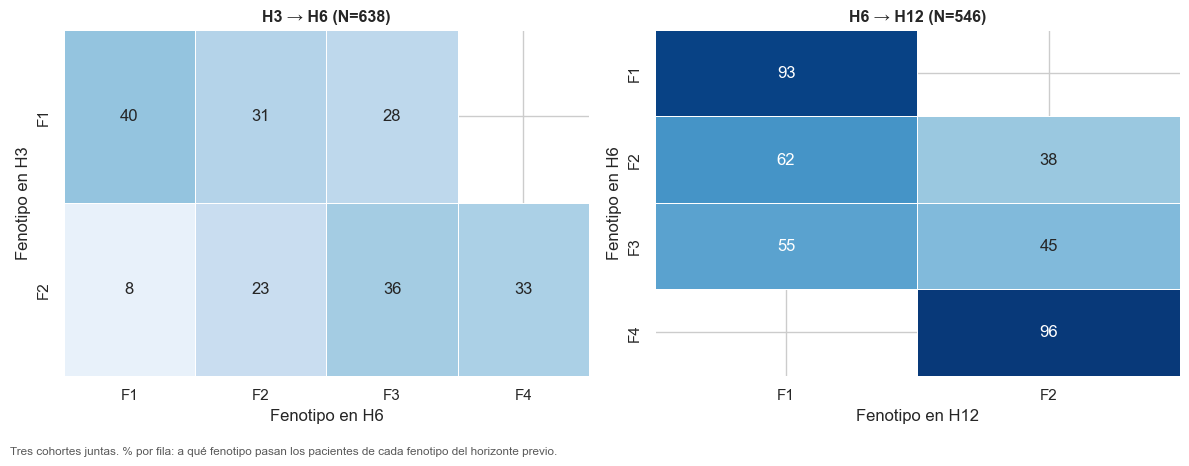

,pacientes comunes,ARI
transición,,
H3 → H6,638,0.10
H6 → H12,546,0.15


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
filas = []
for ax, (h1, h2) in zip(axes, [("H3", "H6"), ("H6", "H12")]):
    r1, r2 = resultados[h1], resultados[h2]
    e1 = pd.Series([nombre_f(c) for c in r1["lab"]], index=r1["desc"].index)
    e2 = pd.Series([nombre_f(c) for c in r2["lab"]], index=r2["desc"].index)
    tabla, ari, n = P.transiciones(e1, e2)
    filas.append({"transición": f"{h1} → {h2}", "pacientes comunes": n, "ARI": round(ari, 2)})
    if n:
        pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
        anot = pct.round(0).astype(int).astype(str).mask(tabla < N_MIN, "<10")
        sns.heatmap(pct.mask(tabla < N_MIN), annot=anot.values, fmt="", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=ax, linewidths=0.5)
    ax.set_xlabel(f"Fenotipo en {h2}"); ax.set_ylabel(f"Fenotipo en {h1}"); ax.set_title(f"{h1} → {h2} (N={n})")
nota(fig, "Tres cohortes juntas. % por fila: a qué fenotipo pasan los pacientes de cada fenotipo del horizonte previo.")
plt.tight_layout(); guardar(fig, "transiciones"); plt.show()
pd.DataFrame(filas).set_index("transición")

##### 2.8.3 ¿El fenotipo a 3 meses anticipa el año?

% con cada desenlace según el fenotipo de H3, por cohorte y en las tres juntas (solo con los desenlaces que recoge cada cohorte).

In [17]:
r = resultados["H3"]
filas, pruebas = [], []
for coh in [None, *COHORTES]:
    dentro = np.ones(len(r["lab"]), bool) if coh is None else (r["desc"]["cohorte_analisis"] == coh).values
    for nombre, v, visitas, regla in PF["desenlaces"]:
        cohs = COHORTES if coh is None else [coh]
        cohs = [c for c in cohs if FP.visitas_que_recogen(cfg, PF, v, c) & set(visitas)]
        if not cohs:
            continue
        y = pd.concat([FP.estado_hasta(medidas, cfg, PF, c, r["desc"].index[(r["desc"]["cohorte_analisis"] == c).values],
                                       v, visitas, regla) for c in cohs]).reindex(r["desc"].index)
        ok = y.notna().values & dentro
        if ok.sum() < N_MIN:
            continue
        etq = "Todas" if coh is None else ETQ[coh]
        ct = pd.crosstab(r["lab"][ok], y.values[ok])
        if ct.shape[1] == 2 and (ct.values > 0).all():
            pruebas.append({"cohorte": etq, "desenlace": nombre, "N": int(ok.sum()), "p (χ²)": f"{stats.chi2_contingency(ct)[1]:.2g}"})
        for c in range(r["k"]):
            s = y.values[ok & (r["lab"] == c)]
            k = int(np.nansum(s))
            if len(s) < N_MIN or 0 < k < N_MIN:
                continue
            lo, hi = ic_wilson(k, len(s))
            filas.append({"cohorte": etq, "desenlace": nombre, "fenotipo H3": nombre_f(c), "N": len(s),
                          "%": round(100 * k / len(s), 1), "IC95": f"{lo:.0f}–{hi:.0f}"})
pronostico = pd.DataFrame(filas)
pronostico.to_csv(TAB / f"{PFX}_pronostico_h3.csv", index=False)
display(pd.DataFrame(pruebas).set_index(["cohorte", "desenlace"]) if pruebas else "sin pruebas evaluables")
pronostico.set_index(["cohorte", "desenlace", "fenotipo H3"]) if len(pronostico) else "sin desenlaces evaluables"

N   p (χ²)
cohorte          desenlace                         
Todas            DLCO < 80 % a 12 m    494  3.6e-05
                 HADS-A ≥ 8 a 12 m     359        1
                 mMRC ≥ 2 a 12 m       352     0.15
                 Reingreso hasta 12 m  955     0.21
CIBERESUCICOVID  DLCO < 80 % a 12 m    226    0.022
                 Reingreso hasta 12 m  955     0.21
POSTCOVID-Lleida DLCO < 80 % a 12 m    217  3.5e-05
                 HADS-A ≥ 8 a 12 m     270     0.57
                 mMRC ≥ 2 a 12 m       262     0.13
TENACITY         DLCO < 80 % a 12 m     51     0.29
                 HADS-A ≥ 8 a 12 m      89     0.38
                 mMRC ≥ 2 a 12 m        90     0.93

N     %   IC95
cohorte          desenlace            fenotipo H3                  
Todas            DLCO < 80 % a 12 m   F1           228  46.9  41–53
                                      F2           266  65.8  60–71
                 HADS-A ≥ 8 a 12 m    F1           157  14.6  10–21
                                      F2           202  14.4  10–20
                 mMRC ≥ 2 a 12 m      F1           153   9.8   6–16
                                      F2           199  15.6  11–21
                 Reingreso hasta 12 m F1           543   8.1   6–11
                                      F2           412  10.7   8–14
CIBERESUCICOVID  DLCO < 80 % a 12 m   F1           124  58.1  49–66
                                      F2           102  73.5  64–81
                 Reingreso hasta 12 m F1           543   8.1   6–11
                                      F2           412  10.7   8–14
POSTCOVID-Lleida DLCO < 80 % a 12 m   F1            84  38.1  28–49
                                      F2           133  67.7  59–75
                 HADS-A ≥ 8 a 12 m    F1           112  15.2  10–23
                                      F2           158  12.0   8–18
                 mMRC ≥ 2 a 12 m      F2           155  15.5  11–22
TENACITY         DLCO < 80 % a 12 m   F2            31  32.3  19–50
                 HADS-A ≥ 8 a 12 m    F2            44  22.7  13–37

#### 2.2.9 Sensibilidad

Se repite cada horizonte cambiando una sola cosa, con menos permutaciones y remuestreos:
- **k = 3 fijo**;
- **sin FEV1** (solo DLCO y FVC);
- **solo difusión** y **solo espirometría**;
- **sin variables de cambio**;
- **`cmd99`** en CIBERESUCICOVID.

In [18]:
cmd99 = set(pacientes.loc[pacientes["cmd99"] | (pacientes["cohorte_analisis"] != "CIBERESUCICOVID"), "subject_id"])
rapido = dict(n_perm=20, n_boot=50)
filas = []
for h, base in resultados.items():
    cols = base["cols"]
    escenarios = {"principal": None, f"k = {PF['k_comparacion']} fijo": dict(k_forzado=PF["k_comparacion"]),
                  "sin FEV1": dict(columnas=[c for c in cols if not c.startswith("fev1_")]),
                  "solo difusión": dict(columnas=[c for c in cols if c.startswith("dlco_")]),
                  "solo espirometría": dict(columnas=[c for c in cols if c.startswith(("fvc_", "fev1_"))]),
                  "cmd99": dict(filtro=lambda d: d.index.isin(cmd99))}
    if any(c.endswith("_cambio") for c in cols):
        escenarios["sin cambios"] = dict(columnas=[c for c in cols if not c.endswith("_cambio")])
    for nombre, kw in escenarios.items():
        r = base if kw is None else ejecutar(h, **kw, **rapido)
        ari_vs = np.nan
        if kw is not None:
            comunes = r["desc"].index.intersection(base["desc"].index)
            ari_vs = adjusted_rand_score(pd.Series(base["lab"], index=base["desc"].index).loc[comunes],
                                         pd.Series(r["lab"], index=r["desc"].index).loc[comunes])
        filas.append({"horizonte": h, "escenario": nombre, "N": len(r["desc"]), "k": r["k"],
                      "estructura": "sí" if r["estructura"] else "no", "silueta": round(r["silueta"], 2),
                      "silueta − nula": round(r["silueta"] - r["nulo"].set_index("k").loc[r["k"], "nulo_media"], 2),
                      "Jaccard estab. (media)": round(r["estab"]["jaccard_medio"].mean(), 2),
                      "ARI frente al principal": round(ari_vs, 2)})
sensibilidad = pd.DataFrame(filas).set_index(["horizonte", "escenario"])
sensibilidad.to_csv(TAB / f"{PFX}_sensibilidad.csv")
privacidad.suprimir_celdas(sensibilidad, N_MIN, ["N"])

N  k estructura  silueta  silueta − nula  Jaccard estab. (media)  ARI frente al principal
horizonte escenario                                                                                                      
H3        principal          1574  2         sí     0.36            0.24                    0.92                      NaN
          k = 3 fijo         1574  3         sí     0.25            0.17                    0.68                     0.46
          sin FEV1           1573  2         sí     0.39            0.23                    0.96                     0.70
          solo difusión      1369  2         no     0.55           -0.00                    0.98                     0.09
          solo espirometría  1562  2         sí     0.50            0.30                    0.96                     0.97
          cmd99              1570  2         sí     0.36            0.25                    0.96                     1.00
H6        principal          1304  4         sí     0.17            0.14                    0.72                      NaN
          k = 3 fijo         1304  3         sí     0.17            0.13                    0.54                     0.35
          sin FEV1           1302  6         sí     0.19            0.09                    0.67                     0.23
          solo difusión      1144  3         sí     0.40            0.12                    0.87                     0.15
          solo espirometría  1297  2         sí     0.44            0.34                    0.93                     0.26
          cmd99              1302  3         sí     0.25            0.20                    0.55                     0.53
          sin cambios        1304  6         sí     0.14            0.14                    0.55                     0.36
H12       principal           934  2         sí     0.29            0.24                    0.89                      NaN
          k = 3 fijo          934  3         sí     0.14            0.10                    0.76                     0.37
          sin FEV1            933  2         sí     0.30            0.19                    0.94                     0.65
          solo difusión       860  2         sí     0.36            0.20                    0.84                     0.05
          solo espirometría   933  2         sí     0.39            0.30                    0.94                     0.82
          cmd99               932  2         sí     0.29            0.23                    0.89                     1.00
          sin cambios         934  2         sí     0.32            0.25                    0.93                     0.77

#### 2.2.10 Preparación para el modelo predictivo (sin ajustarlo)

Se guarda la **tabla base** del modelo futuro:
- **Diana:** fenotipo en H3, H6 y H12, y los desenlaces a 12 meses.
- **Predictores:** las variables del alta **comunes a las tres cohortes** (`fenotipado_comun.predictores_alta`).
- **Cohorte y centro:** para validar dejando fuera cada cohorte o cada centro.

Aquí solo se comprueba su disponibilidad por cohorte; **no se ajusta ningún modelo**.

In [19]:
filas = []
for h, r in resultados.items():
    D_med = FP.gower(r["X"], r["X"][r["med"]], r["R"], r["w"], r["cat"])
    filas.append(pd.DataFrame({"subject_id": r["desc"].index, "horizonte": h,
                               "cohorte_analisis": r["desc"]["cohorte_analisis"].astype(str).values,
                               "fenotipo": [nombre_f(c) for c in r["lab"]],
                               "distancia_medoide": D_med[np.arange(len(r["lab"])), r["lab"]]}))
fenotipos = pd.concat(filas, ignore_index=True)
fenotipos.to_parquet(DATOS / "fenotipos_comun.parquet", index=False)

base = fenotipos.pivot(index="subject_id", columns="horizonte", values="fenotipo").add_prefix("fenotipo_")
pred = pacientes.set_index("subject_id")[["cohorte_analisis", "centro_id", *PF["predictores_alta"]]]
base = pred.join(base, how="inner")
for nombre, v, visitas, regla in PF["desenlaces"]:
    col = "y_" + nombre.split(" ")[0].lower().replace("-", "_")
    partes = [FP.estado_hasta(medidas, cfg, PF, c, base.index[base["cohorte_analisis"] == c], v, visitas, regla)
              for c in COHORTES if FP.visitas_que_recogen(cfg, PF, v, c) & set(visitas)]
    base[col] = pd.concat(partes).reindex(base.index) if partes else np.nan
base.reset_index().to_parquet(DATOS / "base_modelo.parquet", index=False)
print(f"Guardado {DATOS.name}/fenotipos_comun.parquet ({len(fenotipos):,} filas) y "
      f"{DATOS.name}/base_modelo.parquet ({len(base):,} pacientes × {base.shape[1]} columnas)")

disp = base.groupby("cohorte_analisis", observed=True).apply(lambda d: d.notna().mean() * 100, include_groups=False).round(0).T
disp.columns = [ETQ[str(c)] for c in disp.columns]
disp.loc["N pacientes"] = base["cohorte_analisis"].astype(str).value_counts().rename(ETQ)
print("% de pacientes con dato en cada columna de la tabla base:")
disp

Guardado Datos limpios/fenotipos_comun.parquet (3,812 filas) y Datos limpios/base_modelo.parquet (2,439 pacientes × 19 columnas)
% de pacientes con dato en cada columna de la tabla base:


,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY
centro_id,83.0,90.0,57.0
grupo_edad,100.0,98.0,86.0
sexo,100.0,97.0,87.0
estancia_hosp_dias,100.0,96.0,100.0
nu_ingreso_uci,100.0,100.0,100.0
nu_hta,100.0,96.0,100.0
nu_diabetes,100.0,96.0,100.0
nu_card_cronica,100.0,96.0,100.0
nu_epoc,100.0,96.0,100.0
nu_renal_cronica,100.0,96.0,100.0


**Lectura para el modelo:**
- **Dianas.** Los fenotipos existen para todos los pacientes incluidos en cada horizonte. Los desenlaces dependen de lo que recoge cada cohorte: HADS y mMRC no existen en CIBERESUCICOVID, y reingreso no existe en Lleida ni en TENACITY.
- **Predictores.** Los del alta están en las tres cohortes con buena cobertura. La traqueotomía no se incluye porque Lleida no la recoge.
- **Validación prevista:** dejando fuera cada cohorte, y dejando fuera cada centro dentro de CIBERESUCICOVID. Nunca partición aleatoria.

#### 2.2.11 Resumen

**Resultados (ejecución con semilla 2026; ver §2–§10).**

1. **H3 da el fenotipo más sólido de todo el proyecto.** Tiene k = 2, una estructura clara frente al nulo (silueta 0,36 frente a 0,11) y es muy estable (Jaccard 0,92 en los dos grupos):
   - **F1 · "función conservada"** (821 pacientes): DLCO 79 %, FVC 96 %, FEV1 99 %.
   - **F2 · "afectación funcional"** (753): DLCO 65 %, FVC 73 %, FEV1 76 %. Es una alteración mixta, de difusión y de volumen.

   Los nombres son borradores para que los valide el equipo.
2. **No separa cohortes: separa pacientes.** La relación entre fenotipo y cohorte es pequeña (V de Cramér 0,10–0,12). Dentro de cada cohorte, el perfil del fenotipo es casi idéntico: F2 tiene DLCO 64 % y FVC 73 % tanto en CIBERESUCICOVID como en Lleida.
3. **Viaja, al menos a 3 meses.** Al aprender con dos cohortes y comprobar en la tercera:
   - ARI de 0,50 dejando fuera CIBERESUCICOVID, 0,61 dejando fuera Lleida y 0,73 dejando fuera TENACITY;
   - Jaccard por fenotipo de 0,68 a 0,87.

   Es el primer fenotipo que se reproduce razonablemente en cohortes no vistas, aunque los IC son anchos en las cohortes pequeñas.
4. **H6 y H12 son más débiles.**
   - **H6:** k = 4, y un grupo solo es "patrón". Al dejar fuera una cohorte, el ARI baja a ≈ 0,3.
   - **H12:** k = 2 y estable (Jaccard 0,89), pero viaja peor: ARI de 0,34, 0,21 y 0,05 según la cohorte excluida, con IC que incluyen valores bajos.
   - **Transiciones:** los fenotipos cambian entre horizontes (ARI H3 → H6 = 0,10).
5. **Quién sostiene la partición.** La **espirometría**: la versión "solo espirometría" coincide casi del todo con la principal en H3 (ARI 0,97). La difusión sola no tiene estructura en H3. Quitar FEV1 cambia poco (ARI 0,70).
6. **Valor pronóstico.** El fenotipo a 3 meses anticipa la **DLCO < 80 % al año**:
   - 47 % frente a 66 % en las tres cohortes juntas (p < 0,0001);
   - 58 % frente a 74 % en CIBERESUCICOVID (p = 0,02);
   - 38 % frente a 68 % en Lleida (p < 0,0001).

   **No** anticipa ansiedad, disnea ni reingresos: es un fenotipo respiratorio.

**Para el modelo predictivo**
- **Diana recomendada:** el **fenotipo H3** (binario, estable y transferible) o la **DLCO < 80 % al año**. H12 es una diana más débil.
- **Tabla base** en `Datos limpios/base_modelo.parquet`: 2.439 pacientes, con fenotipos, desenlaces y 10 predictores del alta comunes a las tres cohortes (cobertura ≥ 86 %).
- **Validación:** dejando fuera cada cohorte, y cada centro dentro de CIBERESUCICOVID.

**Limitaciones:**
- **Definición solo respiratoria** (DLCO, FVC, FEV1): es lo único que las tres cohortes miden igual. Síntomas, ánimo y esfuerzo describen, no definen.
- **Composición desigual.** CIBERESUCICOVID aporta unos dos tercios de los pacientes y pesa más en el descubrimiento; por eso la validación deja fuera cada cohorte.
- **TENACITY es pequeña en H6 y H12** (unos 60): los IC serán anchos.
- **Abandono informativo** (notebook 01, §8): H12 sobrerrepresenta a quien sigue en seguimiento.
- **No se imputa:** quien tiene pocas medidas pesa con menos información.

## 3. Modelo para clasificación de pacientes